# 자금세탁 탐지 AI — 방향 그래프 GNN 엣지 분류 모델 (IBM AMLworld)

**팀 화두 논의 결론을 반영한, GBT+GFP(팀원 선행 방식)와 차별화된 그래프 신경망(GNN) 기반 파이프라인**

- 데이터: `IBM_AML_dataset/archive (2).zip` (IBM AMLworld 합성 AML 트랜잭션 데이터)
- 판정 단위: **거래(트랜잭션) 1건 = 그래프의 엣지 1개** → **엣지 분류** (화두 1·13·14·16)
- 목표: 데이터를 다양하게 학습시켜 **일반화 성능**이 좋은 탐지 모델

---

## 1. 참고 논문 조사 결과

### 1-1. 전달받은 SSRN 논문 10편 검토

| # | SSRN ID | 논문 제목 | AML 직접 관련 |
|---|---------|-----------|:---:|
| 1 | 5060022 | AI-Powered (Finance) Scholarship (Novy-Marx & Velikov) | ✕ |
| 2 | 5066286 | Simulating the Survey of Professional Forecasters | ✕ |
| 3 | 5116322 | DeepSeek and FinTech: The Democratization of AI | ✕ |
| 4 | 5080998 | Machine Learning for Pairs Trading: a Clustering-based Approach | ✕ |
| 5 | 5089371 | Artificial Intelligence Asset Pricing Models (Kelly et al.) | ✕ |
| 6 | 5119322 | The Natural Language of Finance (Hoberg & Manela) | ✕ |
| 7 | 3737859 | FinRL: Deep RL Library for Automated Stock Trading | ✕ |
| 8 | 5048316 | Large Language Models in Finance: Reasoning | ✕ |
| 9 | 5171819 | Axes that matter: PCA with a difference | ✕ |
| 10 | 5022165 | Look-Ahead Bias in LLMs: Implications in Finance | ✕ |

> **정직한 보고:** 위 10편은 모두 금융×AI 논문이지만, **자금세탁 탐지(AML)를 직접 다루는 논문은 없었습니다.**
> (자산가격결정·LLM·강화학습 트레이딩·페어트레이딩 등이 주제)
> 다만 방법론적 시사점은 반영했습니다 — ⑩ *Look-Ahead Bias*의 교훈(미래 정보 누수 금지)은
> **시간(순서) 기반 분할 + train 구간 통계만으로 스케일러 적합**으로, ⑤·⑨의 교훈(과적합 억제·차원 관리)은
> 정규화/드롭아웃/조기종료 설계로 반영했습니다.

### 1-2. 실제 모델 설계 근거로 사용한 AML 핵심 문헌 (IBM AMLworld 벤치마크 계열)

| 문헌 | 방법 | IBM AML 성능(소수클래스 F1) |
|---|---|---|
| Altman et al., NeurIPS 2023 (arXiv:2306.16424) — 팀원 방식의 원 논문 | GBT + Graph Feature Preprocessor / GNN 베이스라인 | HI-Small ≈ 63~65% |
| **Egressy et al., AAAI 2024 (arXiv:2306.11586) "Provably Powerful GNNs for Directed Multigraphs"** | **GINe + 엣지 업데이트 + 역방향 메시지 전달 + 포트 번호** | HI-Small **≈ 65~68%** (GBT 대비 우위) |
| MEGA-GNN 2024 (arXiv:2412.00241) | 양방향 다중엣지 집계 GNN | HI-Medium ≈ 68~78% (현 SOTA) |

→ **결론: IBM AML 데이터에서 최고 성능 계열은 "방향 멀티그래프 GNN 엣지 분류"** 이며,
이는 팀 화두 결론(계좌=노드, 거래=엣지, 방향 그래프, 병렬 엣지 유지, 엣지 분류)과 정확히 일치합니다.
본 노트북은 Egressy et al.의 핵심 요소(**GINe + 엣지 피처/업데이트 + 역방향 메시지 전달 + 순서 기반 포트/시퀀스 피처**)를 구현합니다.

---

## 2. 팀원 선행 방식(GBT+GFP)과의 차별점

| 항목 | 팀원 방식 (`preprocess_gbt_gfp.py` + `train_gbt.py`) | **본 노트북** |
|---|---|---|
| 모델 | LightGBM / XGBoost (테이블형 GBT) | **GNN (GINe) 엣지 분류** — 그래프 구조를 학습으로 직접 활용 |
| 그래프 활용 | snapml GFP로 그래프 피처를 "미리 계산"해 테이블에 부착 | **메시지 전달로 관계 패턴을 end-to-end 학습** (수작업 그래프 피처 불필요) |
| 시간 정보 | timestamp_epoch, hour_of_day, day_of_week **절대 시간 사용** | **절대 시간 완전 제거, 순서 인덱스/순서 간격만 사용** (화두 10·17 준수) |
| 금액 처리 | 원화폐 금액 그대로 사용 | **통화별 log1p + 통화별 표준화** (화두 8·9 준수) |
| 중복/자기송금 | 처리 없음 | **완전 동일 중복 제거, 자기송금 유지+플래그** (화두 11 준수) |
| 꼬리 구간 | 처리 없음 | **주 기간만 학습, 꼬리 절단** (화두 17 준수) |
| 판정 임계값 | 0.5 고정 | 0.5 + **검증셋 F1 최적 임계값 튜닝** 병행 보고 |
| 일반화 장치 | scale_pos_weight 탐색 | LayerNorm·Dropout·Weight Decay·**검증 PR-AUC 조기종료**·누수 차단 스케일링 |

---

## 3. 화두 결론 → 구현 매핑

| 화두 | 결론 | 본 노트북 구현 |
|---|---|---|
| 1 | 거래 1건씩 판정 | 엣지 단위 이진 분류 |
| 2 | 분 단위 배치 입력 | §11 분 단위 배치 추론 데모 + 지연시간 측정 |
| 3 | 사후(이미 벌어진) 세탁 탐지 | 과거 방향 컨텍스트 윈도우만 사용 |
| 4 | MVP=케이스 조사까지 | §10 고위험 거래 서브그래프 시각화 + 조사노트(JSON) 자동 생성 |
| 7 | 세트 통합 안 함 | `DATASET` 설정값만 바꿔 세트별 개별 실험 |
| 8 | 통화 환산 없이 통화별 표준화 | 통화별 log1p→z-score (train 통계만 사용) |
| 9 | 로그 스케일 변환만 | 극단값 제거/윈저라이징 없음 |
| 10·17 | 절대시간 제거, 순서만 / 꼬리 절단 | 순서 인덱스·순서 간격 피처, 주 기간 자동 절단 |
| 11 | 완전 동일 중복 제거, 자기송금 유지 | `drop_duplicates` + `self_loop` 플래그 |
| 13·14·16 | 계좌=노드, 거래=엣지, 방향 그래프, 병렬 엣지 유지 | PyG 방향 멀티그래프, 병렬 엣지 그대로 |

## ⚠️ 화두 결론대로 진행할 때의 위험성 경고 (요청사항)

| 화두 결론 | 잠재 위험 | 완화책(본 노트북/향후) |
|---|---|---|
| **거래 1건씩 판정** (화두1) | 세탁은 여러 거래가 모인 *패턴* 현상 → 개별 거래 라벨은 노이즈가 크고, 시나리오(팬인/팬아웃/사이클) 전체를 놓칠 수 있음 | GNN이 이웃 거래 맥락을 집계해 완화. 향후 계좌/서브그래프 단위 보조 판정 병행 권장 |
| **분 단위 배치** (화두2) | 거래 급증 시 배치가 커져 지연 SLA 위반 가능. "배치 첫 도착 기준 응답시간"은 뒤에 도착한 거래의 체감 지연을 과소 측정 | §11에서 배치 크기별 지연 측정. 운영 시 배치 크기 상한 + 백프레셔 필요 |
| **사후 탐지** (화두3) | 이미 자금이 빠져나간 뒤 → 자금 동결 실효성↓, STR 보고 지연 리스크 | 탐지 지연 분포를 모니터링 지표로 관리 권장 |
| **통화별 개별 표준화, 환산 안 함** (화두8) | 표본이 적은 통화는 평균/표준편차가 불안정 → 이상한 z-score. 통화 간 금액 비교 불가로 *크로스커런시 레이어링* 패턴 일부 놓침 | 희소 통화는 전체 통계로 폴백 구현. 향후 환산 금액을 보조 피처로 A/B 권장 |
| **로그 변환만, 극단값 방치** (화두9) | 초고액 이상치가 손실/그래디언트를 지배할 수 있음 | z-score가 일부 완화. 학습 불안정 시 클리핑 재논의(팀 합의사항) |
| **절대시간 제거, 순서만** (화두10·17) | 심야/주말 등 *시간대 신호* 완전 손실. 거래량이 몰리는 구간에서는 순서 간격이 실제 시간 간격을 왜곡. 데이터 생성기의 시간 패턴을 못 씀 | 순서 간격(log)으로 시계열성 부분 보존. 성능 미달 시 "상대 시간차(분)" 피처만 제한 도입 재논의 권장 |
| **완전 동일 중복 제거** (화두11) | 실제 금융에서 동일 금액·동일 시각 반복 송금은 그 자체가 *세탁 신호*일 수 있음 → 신호 삭제 위험 | 제거 건수 로그 출력. 제거 전 중복 횟수를 피처로 남기는 방안 재논의 권장 |
| **자기송금 유지** (화두11) | IBM 데이터의 Reinvestment 자기루프가 대량 노이즈로 작용 가능 | `self_loop` 플래그로 모델이 구분 가능하게 함 |
| **꼬리 절단** (화두17) | 꼬리 구간에만 존재하는 세탁 시나리오 유실 + 절단 기준에 따라 평가 분포 변형 | 절단 전/후 시각화 및 유실 라벨 수 출력 |
| **세트 미통합** (화두7) | 단일 세트 학습 모델은 타 은행/타 분포 일반화 검증 불가 | `DATASET` 변경 재실험으로 세트 간 성능 비교(§12 안내) |
| **병렬 엣지 전부 유지** (화두16) | 대형 세트(Large)에서 메모리/속도 병목 | 순서 윈도우 미니배치(§7)로 메모리 상한 고정 |

## 4. 환경 설정

아래 셀의 주석을 해제해 1회 설치하세요. (PyG는 2.3+ 순수 파이썬 설치로 충분 — 별도 C 확장 불필요)

In [1]:
# 최초 1회만 실행하세요 (주석 해제 후):
%pip install pandas numpy matplotlib networkx scikit-learn torch torch_geometric --break-system-packages

import importlib
for pkg in ["pandas", "numpy", "matplotlib", "networkx", "sklearn", "torch", "torch_geometric"]:
    try:
        m = importlib.import_module(pkg)
        print(f"[OK] {pkg} {getattr(m, '__version__', '')}")
    except ImportError:
        print(f"[누락] {pkg}  ->  %pip install {pkg} 필요")

Note: you may need to restart the kernel to use updated packages.
[OK] pandas 3.0.3
[OK] numpy 2.4.1
[OK] matplotlib 3.10.9
[OK] networkx 3.6.1
[OK] sklearn 1.8.0
[OK] torch 2.10.0+cu126
[OK] torch_geometric 2.8.0.post1


In [2]:
import json, os, random, time, warnings, zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (average_precision_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score)
from torch_geometric.nn import GINEConv

warnings.filterwarnings("ignore")
# 한글 폰트 (Windows: Malgun Gothic)
plt.rcParams["font.family"] = ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

# ----------------------------- 설정 -----------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

ZIP_PATH = Path("IBM_AML_dataset/archive (2).zip")   # 데이터 zip 경로 (요구사항)
DATASET  = "HI-Small"        # 화두7: 세트 미통합 — 이 값만 바꿔 세트별 개별 실험 (HI/LI-Small/Medium/Large)
MAX_ROWS = None              # 메모리가 부족하면 예: 2_000_000 으로 제한

TRAIN_FRAC, VAL_FRAC = 0.6, 0.2   # 순서(시간) 기반 60/20/20 분할
TAIL_MIN_FRAC = 0.05              # 화두17: 일 거래량이 중앙값의 5% 미만인 꼬리 구간 절단

WINDOW_SIZE = 100_000             # 순서 윈도우 미니배치 크기 (메모리 상한)
HIDDEN, N_LAYERS, DROPOUT = 64, 2, 0.15
LR, WEIGHT_DECAY = 2e-3, 1e-5
EPOCHS, PATIENCE = 8, 2           # 검증 PR-AUC 기준 조기종료
POS_WEIGHT_CAP = 15.0             # 클래스 불균형 가중 상한

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device = {DEVICE}")

device = cuda


## 5. 데이터 로드 (zip 스트리밍 + 손상 진단 + CSV 폴백)

읽기 우선순위:
1. `ZIP_PATH` 의 zip이 정상이면 → zip 내부에서 직접 스트리밍
2. zip이 없거나 손상이면 → 압축 해제된 CSV를 아래 폴더에서 탐색:
   `IBM_AML_dataset/`, 노트북과 같은 폴더, `ZIP_PATH` 의 부모 폴더

> 💡 **전체 zip은 수십 GB라 서버 업로드 중 잘리기 쉽습니다.**
> 필요한 세트만 압축 해제해서 올리는 것을 권장합니다 — 기본 실험(HI-Small)에 필요한 파일은
> `HI-Small_Trans.csv`(약 454MB)와 `HI-Small_Patterns.txt`(0.3MB) 두 개뿐입니다.
> 두 파일을 `IBM_AML_dataset/` 폴더에 넣으면 zip 없이 그대로 돌아갑니다.

In [14]:
from pathlib import Path
import shutil

targets = {
    "HI-Small_Trans":    ("csv", Path("IBM_AML_dataset/HI-Small_Trans.csv"),    475_664_283),
    "HI-Small_Patterns": ("txt", Path("IBM_AML_dataset/HI-Small_Patterns.txt"), 323_844),
}
Path("IBM_AML_dataset").mkdir(exist_ok=True)

for stem, (ext, dest, expected) in targets.items():
    if dest.exists() and dest.stat().st_size == expected:
        print(f"✅ {dest} 이미 정상"); continue
    # 이름 변형( (5) 등 ) 포함, /workspace와 IBM_AML_dataset에서 탐색
    cands = [c for d in [Path("."), Path("IBM_AML_dataset")]
             for c in d.glob(f"{stem}*.{ext}") if c.resolve() != dest.resolve()]
    if not cands:
        print(f"❌ {stem}*.{ext} 를 서버에서 못 찾음 — 아직 업로드 안 됨"); continue
    cands.sort(key=lambda c: c.stat().st_size != expected)  # 크기 맞는 것 우선
    src = cands[0]; size = src.stat().st_size
    print(f"발견: {src}  ({size:,} bytes)")
    if size != expected:
        print(f"   ❌ 잘린 파일 (정상 {expected:,}) — 재업로드 필요"); continue
    shutil.move(str(src), str(dest))
    print(f"   ✅ {dest} 로 이동·개명 완료")

ok = all(d.exists() and d.stat().st_size == e for (_, d, e) in targets.values())
print("\n" + ("🎉 데이터 준비 완료 — 노트북을 처음부터 실행하세요!" if ok else "⛔ 위 ❌ 메시지 확인"))

✅ IBM_AML_dataset/HI-Small_Trans.csv 이미 정상
✅ IBM_AML_dataset/HI-Small_Patterns.txt 이미 정상

🎉 데이터 준비 완료 — 노트북을 처음부터 실행하세요!


In [15]:
from pathlib import Path

p = Path("IBM_AML_dataset/HI-Small_Trans.csv")
size = p.stat().st_size
print(f"HI-Small_Trans.csv = {size:,} bytes ({size/1e6:.1f} MB)")

if size == 475_664_283:
    print("✅ 완전한 파일 — 노트북을 처음부터 실행하면 됩니다")
elif size < 475_664_283:
    print(f"❌ 잘린 파일 — 정상 크기의 {size/475_664_283*100:.0f}%만 올라옴. 재업로드 필요")
else:
    print("⚠️ 크기가 예상과 다름 — 파일 출처 확인 필요")

HI-Small_Trans.csv = 475,664,283 bytes (475.7 MB)
✅ 완전한 파일 — 노트북을 처음부터 실행하면 됩니다


In [16]:
# ---------- 데이터 소스 준비: zip 검증 → 실패 시 CSV 폴백 ----------
CSV_SEARCH_DIRS = [Path("IBM_AML_dataset"), Path("."), ZIP_PATH.parent]

zf = None
if ZIP_PATH.exists():
    size_mb = ZIP_PATH.stat().st_size / 1e6
    with open(ZIP_PATH, "rb") as fh:
        magic = fh.read(4)
    if magic[:2] == b"PK":
        try:
            zf = zipfile.ZipFile(ZIP_PATH)
            print(f"[zip 정상] {ZIP_PATH} ({size_mb:,.1f} MB)")
        except zipfile.BadZipFile:
            print(f"[zip 손상] {ZIP_PATH} ({size_mb:,.1f} MB) — 시작은 zip(PK)인데 끝부분이 없습니다.")
            print("  → 업로드/복사가 중간에 끊겨 파일이 잘린 상태입니다. 재업로드가 필요합니다.")
            print("  → 또는 로컬 PC에서 압축을 풀어 필요한 CSV만 IBM_AML_dataset/ 폴더에 올리세요(권장).")
    else:
        print(f"[zip 아님] {ZIP_PATH} ({size_mb:,.1f} MB), 시작 바이트 = {magic!r}")
        print("  → zip이 아닌 파일입니다(다운로드 오류 페이지, LFS 포인터 등일 수 있음). 원본을 다시 받으세요.")
else:
    print(f"[zip 없음] {ZIP_PATH.resolve()}")

def open_member(fname):
    # zip이 정상이면 zip에서, 아니면 폴더들에서 압축 해제된 파일을 찾는다
    if zf is not None:
        names = set(zf.namelist())
        if fname in names:
            return zf.open(fname)
        inner = [n for n in names if n.endswith("/" + fname)]
        if inner:
            return zf.open(inner[0])
    for d in CSV_SEARCH_DIRS:
        p = Path(d) / fname
        if p.exists():
            print(f"[파일 사용] {p}")
            return open(p, "rb")
    raise FileNotFoundError(
        f"'{fname}' 를 찾지 못했습니다. zip을 온전히 재업로드하거나, "
        f"압축 해제한 파일을 {[str(Path(d)) for d in CSV_SEARCH_DIRS]} 중 한 곳에 두세요."
    )

t0 = time.time()
with open_member(f"{DATASET}_Trans.csv") as f:
    df = pd.read_csv(
        f,
        dtype={
            "From Bank": str, "Account": str, "To Bank": str, "Account.1": str,
            "Receiving Currency": "category", "Payment Currency": "category",
            "Payment Format": "category", "Is Laundering": np.int8,
        },
        nrows=MAX_ROWS,
    )
df["Timestamp"] = pd.to_datetime(df["Timestamp"], format="%Y/%m/%d %H:%M")
print(f"{len(df):,}건 로드 ({time.time()-t0:.1f}s)")
df.head()

[zip 없음] /workspace/IBM_AML_dataset/archive (2).zip
[파일 사용] IBM_AML_dataset/HI-Small_Trans.csv
5,078,345건 로드 (8.3s)


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering
0,2022-09-01 00:20:00,010,8000EBD30,010,8000EBD30,3697.34,US Dollar,3697.34,US Dollar,Reinvestment,0
1,2022-09-01 00:20:00,03208,8000F4580,001,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0
2,2022-09-01 00:00:00,03209,8000F4670,03209,8000F4670,14675.57,US Dollar,14675.57,US Dollar,Reinvestment,0
3,2022-09-01 00:02:00,012,8000F5030,012,8000F5030,2806.97,US Dollar,2806.97,US Dollar,Reinvestment,0
4,2022-09-01 00:06:00,010,8000F5200,010,8000F5200,36682.97,US Dollar,36682.97,US Dollar,Reinvestment,0


## 6. 전처리 ①  — 중복 제거·정렬·꼬리 절단 (화두 10·11·17)

- **완전 동일 중복** 거래만 제거 (화두 11)
- 시간순 **안정 정렬** 후 절대 시간은 이후 피처에서 사용하지 않음 (화두 10) — `Timestamp` 컬럼은
  분 단위 배치 데모(§11)와 꼬리 절단에만 쓰고 모델 입력에서는 제외
- **주 기간(main period)만 유지**: 일 거래량이 중앙값의 `TAIL_MIN_FRAC` 미만인 꼬리 구간 절단 (화두 17)

In [17]:
n_raw = len(df)

# (화두 11) 완전 동일 중복 제거
df = df.drop_duplicates()
n_dedup = len(df)
print(f"중복 제거: {n_raw - n_dedup:,}건 삭제 ({(n_raw-n_dedup)/n_raw*100:.3f}%)")

# 시간순 안정 정렬
df = df.sort_values("Timestamp", kind="mergesort").reset_index(drop=True)

# (화두 17) 꼬리 절단 — 일 거래량 기준 주 기간 탐지
daily_counts_all = df["Timestamp"].dt.floor("D").value_counts().sort_index()
thr = daily_counts_all.median() * TAIL_MIN_FRAC
good_days = daily_counts_all[daily_counts_all >= thr].index
main_start, main_end = good_days.min(), good_days.max()

day = df["Timestamp"].dt.floor("D")
mask_main = (day >= main_start) & (day <= main_end)
lost_pos = int(df.loc[~mask_main, "Is Laundering"].sum())
print(f"주 기간: {main_start.date()} ~ {main_end.date()}  "
      f"(절단 {int((~mask_main).sum()):,}건, 그중 세탁 라벨 {lost_pos}건 유실 — 경고 섹션 참조)")
df = df[mask_main].reset_index(drop=True)
n = len(df)
print(f"최종 {n:,}건, 세탁 비율 {df['Is Laundering'].mean()*100:.4f}%")

중복 제거: 9건 삭제 (0.000%)
주 기간: 2022-09-01 ~ 2022-09-10  (절단 1,108건, 그중 세탁 라벨 655건 유실 — 경고 섹션 참조)
최종 5,077,228건, 세탁 비율 0.0891%


## 7. 전처리 ② — 피처 엔지니어링 (화두 8·9·10·16)

**누수 차단 원칙 (SSRN ⑩ Look-Ahead Bias 교훈):** 분할 경계를 먼저 정하고,
모든 스케일러/카테고리 통계는 **train 구간에서만** 적합합니다.

| 피처 | 설명 | 화두 |
|---|---|---|
| `amt_paid_z`, `amt_recv_z` | **통화별** log1p → z-score (train 통계) | 8·9 |
| `cur_mismatch`, `amt_neq` | 지불/수취 통화 불일치, 금액 불일치(환전) 플래그 | 8 |
| `pf_*`, `pc_*`, `rc_*` | 결제수단·통화 원-핫 (train 기준 카테고리) | — |
| `self_loop` | 자기송금 플래그 (유지 방침) | 11 |
| `src_seq`, `dst_seq` | 해당 계좌의 몇 번째 송금/수취인지 (순서 누적, log 정규화) | 10 |
| `src_gap`, `dst_gap` | 같은 계좌의 직전 거래와의 **순서 간격** (log 정규화) — 절대 시간 아님 | 10 |
| `src_first`, `dst_first` | 계좌의 첫 등장 여부 | 10 |

절대 시간(시각·요일·날짜) 피처는 **일절 사용하지 않습니다** (화두 10).

In [18]:
# 순서 인덱스 (화두 10: 절대시간 제거, 순서만)
df["order_idx"] = np.arange(n, dtype=np.int64)

# 순서(시간) 기반 60/20/20 분할 경계 — 통계 적합 전에 먼저 확정 (누수 차단)
n_tr = int(n * TRAIN_FRAC)
n_va = int(n * (TRAIN_FRAC + VAL_FRAC))
split = np.full(n, "test", dtype=object)
split[:n_tr] = "train"; split[n_tr:n_va] = "val"
df["split"] = split
is_train = df["split"].eq("train").to_numpy()
print(f"train {n_tr:,} / val {n_va-n_tr:,} / test {n-n_va:,}")

# (화두 13·16) 계좌 = (은행, 계좌번호) 쌍 → 정수 노드 ID (방향 그래프의 정점)
src_key = df["From Bank"].astype(str) + "_" + df["Account"].astype(str)
dst_key = df["To Bank"].astype(str) + "_" + df["Account.1"].astype(str)
codes, uniques = pd.factorize(pd.concat([src_key, dst_key], ignore_index=True))
df["src_id"] = codes[:n].astype(np.int64)
df["dst_id"] = codes[n:].astype(np.int64)
NUM_ACCOUNTS = len(uniques)
print(f"계좌(노드) 수: {NUM_ACCOUNTS:,}")

# (화두 11) 자기송금 플래그 (제거하지 않고 유지)
df["self_loop"] = (df["src_id"] == df["dst_id"]).astype(np.float32)
print(f"자기송금: {int(df['self_loop'].sum()):,}건 유지")

train 3,046,336 / val 1,015,446 / test 1,015,446
계좌(노드) 수: 515,078
자기송금: 590,819건 유지


In [19]:
# (화두 8·9) 통화별 log1p → z-score. 통화 환산 없음. train 통계만 사용, 희소/미등장 통화는 전체 통계로 폴백.
def per_currency_z(amount_col, currency_col):
    la = np.log1p(df[amount_col].clip(lower=0).to_numpy(dtype=np.float64))
    cur = df[currency_col].astype(str)
    s = pd.DataFrame({"cur": cur, "la": la})
    st = s[is_train].groupby("cur")["la"].agg(["mean", "std"])
    st["std"] = st["std"].replace(0, np.nan)
    g_mean = s.loc[is_train, "la"].mean()
    g_std = s.loc[is_train, "la"].std()
    m = cur.map(st["mean"]).astype(np.float64).fillna(g_mean).to_numpy()
    sd = cur.map(st["std"]).astype(np.float64).fillna(g_std).to_numpy()
    return ((la - m) / sd).astype(np.float32)

df["amt_paid_z"] = per_currency_z("Amount Paid", "Payment Currency")
df["amt_recv_z"] = per_currency_z("Amount Received", "Receiving Currency")
df["cur_mismatch"] = (df["Payment Currency"].astype(str) != df["Receiving Currency"].astype(str)).astype(np.float32)
df["amt_neq"] = (df["Amount Paid"] != df["Amount Received"]).astype(np.float32)

# 카테고리 원-핫 (train에 등장한 카테고리 기준 — 미등장 값은 전부 0)
def onehot_from_train(col, prefix, max_cats=20):
    cats = df.loc[is_train, col].astype(str).value_counts().index[:max_cats].tolist()
    v = df[col].astype(str)
    out = pd.DataFrame({f"{prefix}_{c}": (v == c).astype(np.float32) for c in cats}, index=df.index)
    return out, cats

pf_oh, PF_CATS = onehot_from_train("Payment Format", "pf")
pc_oh, PC_CATS = onehot_from_train("Payment Currency", "pc")
rc_oh, RC_CATS = onehot_from_train("Receiving Currency", "rc")
df = pd.concat([df, pf_oh, pc_oh, rc_oh], axis=1)

# (화두 10) 순서 기반 시퀀스/간격 피처 — 과거 방향 정보만 사용 (shift(1)), 절대 시간 없음
logN = np.log1p(n)
for role, key in [("src", "src_id"), ("dst", "dst_id")]:
    g = df.groupby(key)["order_idx"]
    seq = g.cumcount()
    prev = g.shift(1)
    gap = df["order_idx"] - prev
    df[f"{role}_seq"] = (np.log1p(seq) / logN).astype(np.float32)
    df[f"{role}_first"] = prev.isna().astype(np.float32)
    df[f"{role}_gap"] = (np.log1p(gap.fillna(n)) / logN).astype(np.float32)

EDGE_FEATURES = (
    ["amt_paid_z", "amt_recv_z", "cur_mismatch", "amt_neq", "self_loop",
     "src_seq", "src_first", "src_gap", "dst_seq", "dst_first", "dst_gap"]
    + list(pf_oh.columns) + list(pc_oh.columns) + list(rc_oh.columns)
)
print(f"엣지 피처 {len(EDGE_FEATURES)}차원")

엣지 피처 48차원


## 8. 탐색적 데이터 분석(EDA) 시각화

In [25]:
!apt-get update -qq && apt-get install -y fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 84 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu noble/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 5s (1979 kB/s)      
debconf: delaying package configuration, since apt-utils is not installed
Selecting previously unselected package fonts-nanum.
(Reading database ... 21687 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...


In [26]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 설치된 나눔고딕 폰트 파일 등록
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

# Matplotlib 기본 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

print("✅ 한글 폰트 설정 완료!")

✅ 한글 폰트 설정 완료!


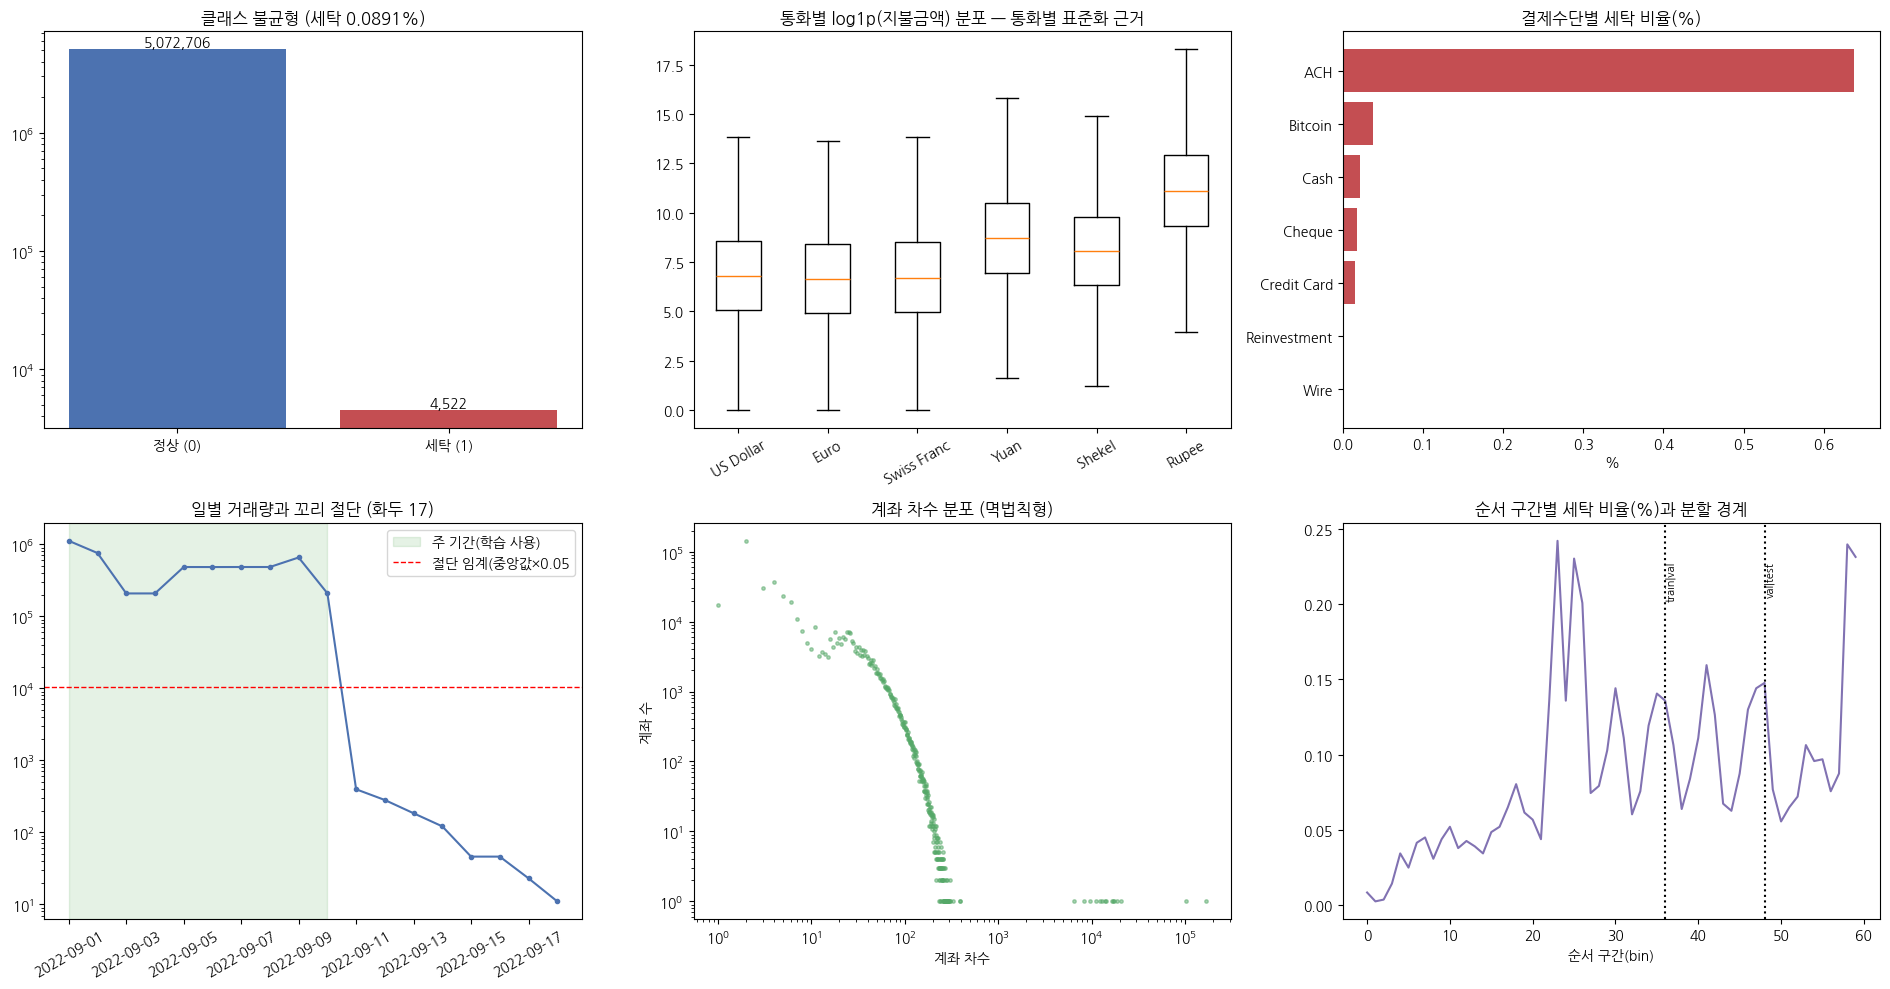

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(19, 10))

# (1) 클래스 불균형
ax = axes[0, 0]
vc = df["Is Laundering"].value_counts()
bars = ax.bar(["정상 (0)", "세탁 (1)"], vc.reindex([0, 1]).values, color=["#4C72B0", "#C44E52"])
ax.set_yscale("log"); ax.set_title(f"클래스 불균형 (세탁 {df['Is Laundering'].mean()*100:.4f}%)")
for b, v in zip(bars, vc.reindex([0, 1]).values):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,}", ha="center", va="bottom")

# (2) 상위 통화별 금액 분포 (log1p) — 화두 8 근거: 통화별 스케일 상이
ax = axes[0, 1]
top_cur = df["Payment Currency"].astype(str).value_counts().index[:6]
data = [np.log1p(df.loc[df["Payment Currency"].astype(str) == c, "Amount Paid"].clip(lower=0)) for c in top_cur]
ax.boxplot(data, showfliers=False)
ax.set_xticklabels(list(top_cur), rotation=30)  # matplotlib 신·구버전 모두 호환
ax.set_title("통화별 log1p(지불금액) 분포 — 통화별 표준화 근거")

# (3) 결제수단별 세탁 비율
ax = axes[0, 2]
rate = df.groupby(df["Payment Format"].astype(str))["Is Laundering"].mean().sort_values() * 100
ax.barh(rate.index, rate.values, color="#C44E52")
ax.set_title("결제수단별 세탁 비율(%)"); ax.set_xlabel("%")

# (4) 일별 거래량 + 주 기간(꼬리 절단) 경계 — 화두 17
ax = axes[1, 0]
ax.plot(daily_counts_all.index, daily_counts_all.values, marker="o", ms=3, color="#4C72B0")
ax.axvspan(main_start, main_end, color="green", alpha=0.10, label="주 기간(학습 사용)")
ax.axhline(thr, color="red", ls="--", lw=1, label=f"절단 임계(중앙값×{TAIL_MIN_FRAC}")
ax.set_yscale("log"); ax.legend(); ax.set_title("일별 거래량과 꼬리 절단 (화두 17)")
ax.tick_params(axis="x", rotation=30)

# (5) 계좌 차수(degree) 분포 (log-log) — 그래프 접근의 근거
ax = axes[1, 1]
deg = np.bincount(np.concatenate([df["src_id"].to_numpy(), df["dst_id"].to_numpy()]))
dv, dc = np.unique(deg[deg > 0], return_counts=True)
ax.scatter(dv, dc, s=6, alpha=0.5, color="#55A868")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("계좌 차수"); ax.set_ylabel("계좌 수"); ax.set_title("계좌 차수 분포 (멱법칙형)")

# (6) 순서 축에서의 세탁 비율 + 분할 경계 — 화두 10 (순서 기반 시계열성)
ax = axes[1, 2]
bins = 60
bin_idx = (df["order_idx"] // max(1, n // bins)).clip(upper=bins - 1)
br = df.groupby(bin_idx)["Is Laundering"].mean() * 100
ax.plot(br.index, br.values, color="#8172B2")
for b, lab in [(n_tr / (n / bins), "train|val"), (n_va / (n / bins), "val|test")]:
    ax.axvline(b, color="k", ls=":")
    ax.text(b, ax.get_ylim()[1]*0.9 if ax.get_ylim()[1] else 0.1, lab, rotation=90, va="top", fontsize=8)
ax.set_title("순서 구간별 세탁 비율(%)과 분할 경계"); ax.set_xlabel("순서 구간(bin)")

plt.tight_layout(); plt.show()

### 8-1. 실제 세탁 패턴 서브그래프 시각화 (`*_Patterns.txt`)

데이터 생성기가 남긴 정답 세탁 시나리오(FAN-OUT, CYCLE 등)를 그래프로 확인합니다 —
"계좌=노드, 거래=엣지, 방향 그래프" 결정(화두 13·14·16)이 타당한 이유를 눈으로 보여주는 자료입니다.

[파일 사용] IBM_AML_dataset/HI-Small_Patterns.txt
세탁 시나리오 블록 370개 파싱


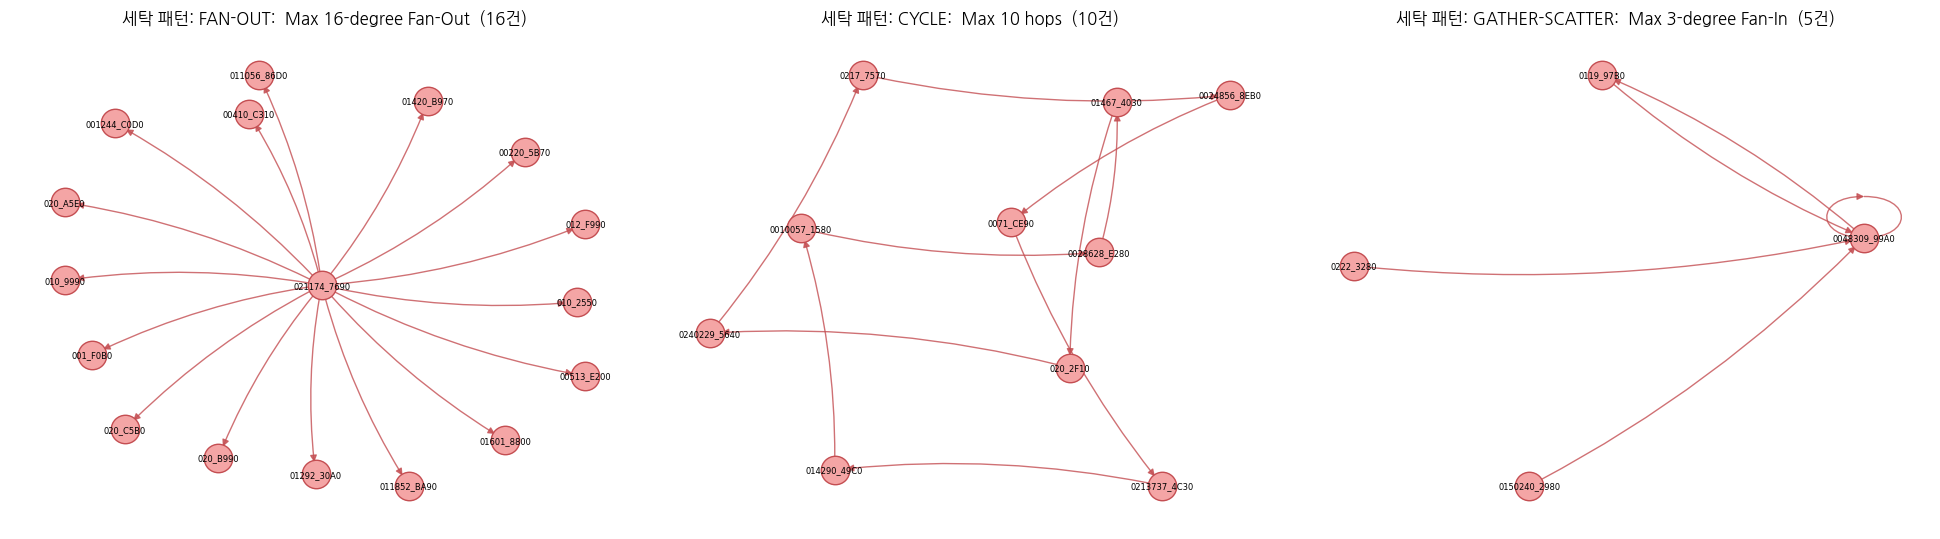

In [28]:
with open_member(f"{DATASET}_Patterns.txt") as f:
    pat_lines = f.read().decode("utf-8", errors="ignore").splitlines()

pattern_blocks, cur = [], None
for ln in pat_lines:
    if ln.startswith("BEGIN LAUNDERING ATTEMPT"):
        cur = {"name": ln.split("-", 1)[-1].strip(), "rows": []}
    elif ln.startswith("END LAUNDERING ATTEMPT"):
        if cur and cur["rows"]:
            pattern_blocks.append(cur)
        cur = None
    elif cur is not None and ln.strip():
        parts = ln.split(",")
        if len(parts) >= 11:
            cur["rows"].append(parts)
print(f"세탁 시나리오 블록 {len(pattern_blocks):,}개 파싱")

# 서로 다른 유형 3개 골라 시각화
seen_types, picks = set(), []
for b in pattern_blocks:
    t = b["name"].split(":")[0].strip()
    if t not in seen_types and 3 <= len(b["rows"]) <= 40:
        seen_types.add(t); picks.append(b)
    if len(picks) == 3:
        break

fig, axes = plt.subplots(1, len(picks), figsize=(6.5 * len(picks), 5.5))
axes = np.atleast_1d(axes)
for ax, blk in zip(axes, picks):
    G = nx.MultiDiGraph()
    for r in blk["rows"]:
        u = f"{r[1]}_{r[2][-4:]}"; v = f"{r[3]}_{r[4][-4:]}"
        G.add_edge(u, v)
    pos = nx.spring_layout(G, seed=SEED, k=1.2)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=420, node_color="#F4A5A5", edgecolors="#C44E52")
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#C44E52", arrows=True,
                           connectionstyle="arc3,rad=0.08", alpha=0.8)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=6)
    ax.set_title(f"세탁 패턴: {blk['name']}  ({len(blk['rows'])}건)")
    ax.axis("off")
plt.tight_layout(); plt.show()

## 9. 그래프 구성과 GNN 모델

### 순서 윈도우 미니배치 (화두 2·16 반영, 메모리 상한 고정)
- 정렬된 거래를 `WINDOW_SIZE`개씩 **연속 구간(윈도우)** 으로 잘라, 윈도우마다 방향 멀티그래프를 구성해 학습/추론합니다.
- 배포 시 "분 단위 배치 + 과거 컨텍스트" 구조와 동일한 형태라, 학습-서빙 간 괴리가 없습니다.
- 병렬 엣지(같은 계좌쌍의 여러 거래)는 **각각 개별 엣지**로 유지됩니다 (화두 16).

### 모델: GINe + 엣지 업데이트 + 역방향 메시지 전달 (Egressy et al., AAAI 2024)
- **GINEConv**: 엣지 피처를 메시지에 반영하는 GIN 변형
- **역방향 메시지 전달**: 역방향 엣지를 방향 플래그와 함께 추가 → 수취→송금 방향 정보도 전파
  (팬인/팬아웃 양쪽 패턴 포착 — 논문에서 소수클래스 F1 개선의 핵심 요소)
- **엣지 업데이트**: 각 층에서 엣지 표현을 [송금노드, 수취노드, 엣지] 로 갱신
- 분류 헤드: `[h_송금, h_수취, e_거래] → 위험도 로짓` (엣지=거래 단위 판정, 화두 1·14)
- 노드 피처는 윈도우 내 in/out 차수와 평균 금액(z) — **계좌 ID 임베딩을 쓰지 않아** 계좌 암기를 차단(일반화)

In [29]:
SRC = df["src_id"].to_numpy()
DST = df["dst_id"].to_numpy()
Y = df["Is Laundering"].to_numpy().astype(np.float32)
EF = np.ascontiguousarray(df[EDGE_FEATURES].to_numpy(dtype=np.float32))
A_PAID = df["amt_paid_z"].to_numpy()
A_RECV = df["amt_recv_z"].to_numpy()

def build_window(lo, hi):
    # [lo, hi) 구간 거래로 방향 멀티그래프 구성 (+역방향 엣지)
    m = hi - lo
    s, d = SRC[lo:hi], DST[lo:hi]
    nodes, inv = np.unique(np.concatenate([s, d]), return_inverse=True)
    sl, dl = inv[:m].astype(np.int64), inv[m:].astype(np.int64)
    nn_ = len(nodes)

    # 윈도우-로컬 노드 피처 (계좌 ID 임베딩 미사용 → 일반화)
    out_deg = np.bincount(sl, minlength=nn_).astype(np.float32)
    in_deg = np.bincount(dl, minlength=nn_).astype(np.float32)
    mean_out = np.bincount(sl, weights=A_PAID[lo:hi], minlength=nn_) / np.maximum(out_deg, 1)
    mean_in = np.bincount(dl, weights=A_RECV[lo:hi], minlength=nn_) / np.maximum(in_deg, 1)
    x = np.stack([np.log1p(out_deg), np.log1p(in_deg),
                  mean_out.astype(np.float32), mean_in.astype(np.float32)], axis=1)

    # 역방향 메시지 전달용 엣지 추가 (방향 플래그 [1,0]=정방향, [0,1]=역방향)
    ei = np.stack([sl, dl])
    ei_full = np.concatenate([ei, ei[::-1]], axis=1)
    ea = EF[lo:hi]
    dirflag = np.zeros((2 * m, 2), dtype=np.float32)
    dirflag[:m, 0] = 1.0; dirflag[m:, 1] = 1.0
    ea_full = np.concatenate([np.concatenate([ea, ea], axis=0), dirflag], axis=1)

    return (torch.from_numpy(x), torch.from_numpy(ei_full),
            torch.from_numpy(ea_full), torch.from_numpy(Y[lo:hi]), m)

def window_ranges(lo, hi, size):
    return [(a, min(a + size, hi)) for a in range(lo, hi, size)]

TRAIN_W = window_ranges(0, n_tr, WINDOW_SIZE)
VAL_W = window_ranges(n_tr, n_va, WINDOW_SIZE)
TEST_W = window_ranges(n_va, n, WINDOW_SIZE)
NODE_DIM, EDGE_DIM = 4, len(EDGE_FEATURES) + 2
print(f"윈도우: train {len(TRAIN_W)} / val {len(VAL_W)} / test {len(TEST_W)}  (크기 {WINDOW_SIZE:,})")

윈도우: train 31 / val 11 / test 11  (크기 100,000)


In [30]:
class EdgeGINe(nn.Module):
    # GINe + 엣지 업데이트 + 역방향 메시지 전달 (Egressy et al., AAAI 2024 방식)
    def __init__(self, node_dim, edge_dim, hidden=64, layers=2, dropout=0.15):
        super().__init__()
        self.node_in = nn.Linear(node_dim, hidden)
        self.edge_in = nn.Linear(edge_dim, hidden)
        self.convs, self.eupds, self.norms = nn.ModuleList(), nn.ModuleList(), nn.ModuleList()
        for _ in range(layers):
            mlp = nn.Sequential(nn.Linear(hidden, hidden), nn.ReLU(), nn.Linear(hidden, hidden))
            self.convs.append(GINEConv(mlp, train_eps=True, edge_dim=hidden))
            self.eupds.append(nn.Sequential(nn.Linear(3 * hidden, hidden), nn.ReLU(),
                                            nn.Linear(hidden, hidden)))
            self.norms.append(nn.LayerNorm(hidden))
        self.dropout = dropout
        self.head = nn.Sequential(nn.Linear(3 * hidden, hidden), nn.ReLU(),
                                  nn.Dropout(dropout), nn.Linear(hidden, 1))

    def forward(self, x, ei, ea, m):
        h = self.node_in(x)
        e = self.edge_in(ea)
        for conv, eupd, norm in zip(self.convs, self.eupds, self.norms):
            h = F.relu(norm(conv(h, ei, e)))
            h = F.dropout(h, self.dropout, self.training)
            e = e + eupd(torch.cat([h[ei[0]], h[ei[1]], e], dim=1))   # 엣지 업데이트
        # 정방향(원본) 엣지 m개만 분류 (화두 1·14: 거래=엣지 단위 판정)
        z = torch.cat([h[ei[0, :m]], h[ei[1, :m]], e[:m]], dim=1)
        return self.head(z).squeeze(-1)

model = EdgeGINe(NODE_DIM, EDGE_DIM, HIDDEN, N_LAYERS, DROPOUT).to(DEVICE)
print(model)
print(f"파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

EdgeGINe(
  (node_in): Linear(in_features=4, out_features=64, bias=True)
  (edge_in): Linear(in_features=50, out_features=64, bias=True)
  (convs): ModuleList(
    (0-1): 2 x GINEConv(nn=Sequential(
      (0): Linear(in_features=64, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
    ))
  )
  (eupds): ModuleList(
    (0-1): 2 x Sequential(
      (0): Linear(in_features=192, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=64, bias=True)
    )
  )
  (norms): ModuleList(
    (0-1): 2 x LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (head): Sequential(
    (0): Linear(in_features=192, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.15, inplace=False)
    (3): Linear(in_features=64, out_features=1, bias=True)
  )
)
파라미터 수: 74,243


## 10. 학습 — 검증 PR-AUC 조기종료 (일반화 우선)

- 손실: `BCEWithLogitsLoss(pos_weight)` — 불균형 보정 (상한 `POS_WEIGHT_CAP`)
- 에폭마다 train 윈도우 **순서를 셔플**(윈도우 내부 순서는 유지 → 시계열성 보존, 화두 10)
- 모델 선택: **검증 PR-AUC(average precision)** 최고 시점 — 임계값에 무관한 지표라
  고정 임계값 0.5로 뽑는 것보다 일반화에 유리

train 세탁 2,297건 / pos_weight=15.0
epoch  1/8  loss=0.1197  val PR-AUC=0.0095  (5s)  <- best
epoch  2/8  loss=0.0594  val PR-AUC=0.0185  (4s)  <- best
epoch  3/8  loss=0.0447  val PR-AUC=0.2015  (5s)  <- best
epoch  4/8  loss=0.0347  val PR-AUC=0.3150  (5s)  <- best
epoch  5/8  loss=0.0291  val PR-AUC=0.4029  (5s)  <- best
epoch  6/8  loss=0.0268  val PR-AUC=0.4468  (5s)  <- best
epoch  7/8  loss=0.0256  val PR-AUC=0.4777  (5s)  <- best
epoch  8/8  loss=0.0247  val PR-AUC=0.4937  (5s)  <- best
best val PR-AUC = 0.4937


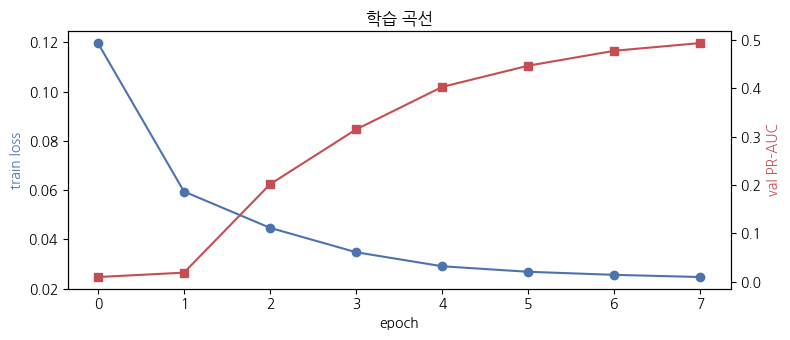

In [31]:
pos = float(Y[:n_tr].sum()); neg = float(n_tr - pos)
pos_weight = torch.tensor(min(neg / max(pos, 1.0), POS_WEIGHT_CAP), device=DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
print(f"train 세탁 {int(pos):,}건 / pos_weight={pos_weight.item():.1f}")

@torch.no_grad()
def predict_windows(windows):
    model.eval()
    probs, ys = [], []
    for lo, hi in windows:
        x, ei, ea, y, m = build_window(lo, hi)
        logit = model(x.to(DEVICE), ei.to(DEVICE), ea.to(DEVICE), m)
        probs.append(torch.sigmoid(logit).cpu().numpy())
        ys.append(y.numpy())
    return np.concatenate(probs), np.concatenate(ys)

history = {"train_loss": [], "val_ap": []}
best_ap, best_state, patience_left = -1.0, None, PATIENCE

for epoch in range(1, EPOCHS + 1):
    model.train()
    ep_loss, order = 0.0, np.random.permutation(len(TRAIN_W))
    t_ep = time.time()
    for wi in order:
        lo, hi = TRAIN_W[wi]
        x, ei, ea, y, m = build_window(lo, hi)
        optimizer.zero_grad()
        logit = model(x.to(DEVICE), ei.to(DEVICE), ea.to(DEVICE), m)
        loss = criterion(logit, y.to(DEVICE))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        optimizer.step()
        ep_loss += loss.item()
    ep_loss /= len(TRAIN_W)

    val_prob, val_y = predict_windows(VAL_W)
    val_ap = average_precision_score(val_y, val_prob)
    history["train_loss"].append(ep_loss); history["val_ap"].append(val_ap)
    marker = ""
    if val_ap > best_ap:
        best_ap, patience_left = val_ap, PATIENCE
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        marker = "  <- best"
    else:
        patience_left -= 1
    print(f"epoch {epoch:>2}/{EPOCHS}  loss={ep_loss:.4f}  val PR-AUC={val_ap:.4f}  "
          f"({time.time()-t_ep:.0f}s){marker}")
    if patience_left == 0:
        print("조기종료 (검증 PR-AUC 개선 없음)")
        break

model.load_state_dict(best_state)
print(f"best val PR-AUC = {best_ap:.4f}")

fig, ax1 = plt.subplots(figsize=(8, 3.5))
ax1.plot(history["train_loss"], "o-", color="#4C72B0", label="train loss")
ax1.set_xlabel("epoch"); ax1.set_ylabel("train loss", color="#4C72B0")
ax2 = ax1.twinx()
ax2.plot(history["val_ap"], "s-", color="#C44E52", label="val PR-AUC")
ax2.set_ylabel("val PR-AUC", color="#C44E52")
plt.title("학습 곡선"); plt.tight_layout(); plt.show()

## 11. 평가 — 소수클래스 Precision / Recall / F1 (테스트셋)

팀원 방식과 동일한 프로토콜(0.5 임계값) **+** 검증셋에서 F1 최적 임계값을 튜닝한 결과를 병행 보고합니다.

검증셋 최적 임계값 = 0.6107 (val F1=53.87%)
테스트 PR-AUC = 0.4535

[테스트 @0.5 (팀원 프로토콜과 동일)] 임계값=0.5000  Precision=53.51%  Recall=43.39%  F1=47.92%
[테스트 @튜닝 임계값] 임계값=0.6107  Precision=64.21%  Recall=41.12%  F1=50.13%


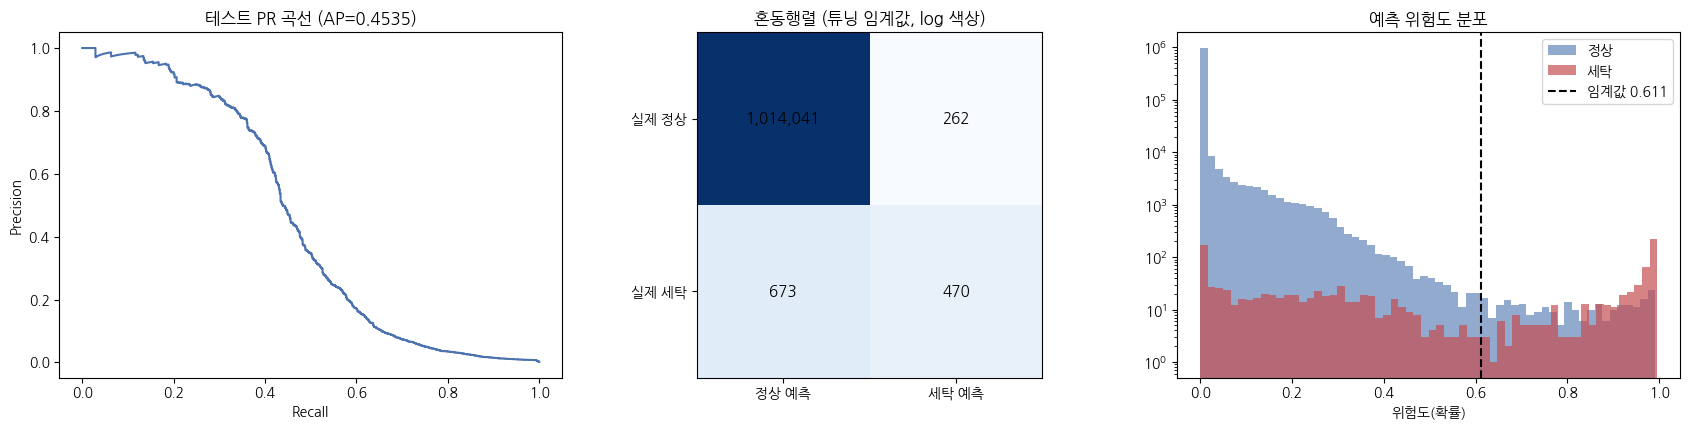

In [32]:
val_prob, val_y = predict_windows(VAL_W)
test_prob, test_y = predict_windows(TEST_W)

# 검증셋 F1 최적 임계값 탐색
prec_c, rec_c, thr_c = precision_recall_curve(val_y, val_prob)
f1_c = 2 * prec_c * rec_c / np.maximum(prec_c + rec_c, 1e-12)
best_i = int(np.nanargmax(f1_c[:-1]))
TUNED_THR = float(thr_c[best_i])
print(f"검증셋 최적 임계값 = {TUNED_THR:.4f} (val F1={f1_c[best_i]*100:.2f}%)")

def report(y_true, y_prob, threshold, name):
    y_pred = (y_prob >= threshold).astype(int)
    p = precision_score(y_true, y_pred, pos_label=1, zero_division=0) * 100
    r = recall_score(y_true, y_pred, pos_label=1, zero_division=0) * 100
    f = f1_score(y_true, y_pred, pos_label=1, zero_division=0) * 100
    print(f"[{name}] 임계값={threshold:.4f}  Precision={p:.2f}%  Recall={r:.2f}%  F1={f:.2f}%")
    return y_pred

test_ap = average_precision_score(test_y, test_prob)
print(f"테스트 PR-AUC = {test_ap:.4f}\n")
_ = report(test_y, test_prob, 0.5, "테스트 @0.5 (팀원 프로토콜과 동일)")
test_pred = report(test_y, test_prob, TUNED_THR, "테스트 @튜닝 임계값")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.4))

# (1) PR 곡선
tp_c, tr_c, _ = precision_recall_curve(test_y, test_prob)
axes[0].plot(tr_c, tp_c, color="#4C72B0")
axes[0].set_xlabel("Recall"); axes[0].set_ylabel("Precision")
axes[0].set_title(f"테스트 PR 곡선 (AP={test_ap:.4f})")

# (2) 혼동행렬 (튜닝 임계값)
cm = confusion_matrix(test_y, test_pred)
im = axes[1].imshow(np.log1p(cm), cmap="Blues")
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                     color="black", fontsize=11)
axes[1].set_xticks([0, 1], ["정상 예측", "세탁 예측"])
axes[1].set_yticks([0, 1], ["실제 정상", "실제 세탁"])
axes[1].set_title("혼동행렬 (튜닝 임계값, log 색상)")

# (3) 점수 분포
axes[2].hist(test_prob[test_y == 0], bins=60, alpha=0.6, label="정상", color="#4C72B0", log=True)
axes[2].hist(test_prob[test_y == 1], bins=60, alpha=0.7, label="세탁", color="#C44E52", log=True)
axes[2].axvline(TUNED_THR, color="k", ls="--", label=f"임계값 {TUNED_THR:.3f}")
axes[2].legend(); axes[2].set_title("예측 위험도 분포"); axes[2].set_xlabel("위험도(확률)")
plt.tight_layout(); plt.show()

In [36]:
# 정확도(Accuracy) 계산 — 참고용
# 주의: 세탁 비율이 0.089%인 극단적 불균형 데이터라 모든 거래를 "정상"으로만 찍어도
# 정확도 ~99.91%가 나옵니다. 모델 비교에는 위의 Precision/Recall/F1/PR-AUC를 쓰세요.
from sklearn.metrics import accuracy_score, confusion_matrix

baseline_acc = accuracy_score(test_y, np.zeros_like(test_y)) * 100
print(f"기준선(전부 정상 예측) 정확도 = {baseline_acc:.4f}%\n")

for thr, name in [(0.5, "@0.5"), (TUNED_THR, "@튜닝 임계값")]:
    y_pred = (test_prob >= thr).astype(int)
    acc = accuracy_score(test_y, y_pred) * 100
    tn, fp, fn, tp = confusion_matrix(test_y, y_pred).ravel()
    print(f"[테스트 {name}] 임계값={thr:.4f}  정확도={acc:.4f}%")
    print(f"  TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}  (오류 합계 {fp+fn:,}건 / 전체 {len(test_y):,}건)")

기준선(전부 정상 예측) 정확도 = 99.8874%

[테스트 @0.5] 임계값=0.5000  정확도=99.8938%
  TP=496  FP=431  FN=647  TN=1,013,872  (오류 합계 1,078건 / 전체 1,015,446건)
[테스트 @튜닝 임계값] 임계값=0.6107  정확도=99.9079%
  TP=470  FP=262  FN=673  TN=1,014,041  (오류 합계 935건 / 전체 1,015,446건)


## 12. 케이스 조사 지원 (화두 4 — MVP 범위)

모니터링에서 이관된 고위험 거래에 대해 조사자가 보는 화면의 원형:
1. **고위험 거래 Top-K** 추출
2. 해당 거래 주변의 **계좌 관계 서브그래프** 시각화 (과거 컨텍스트 윈도우 내 1-hop 이웃)
3. 조사노트 초안(JSON) 자동 생성 → `case_notes/` 저장
   (추후 STR 초안 LLM의 입력으로 확장 가능한 구조)

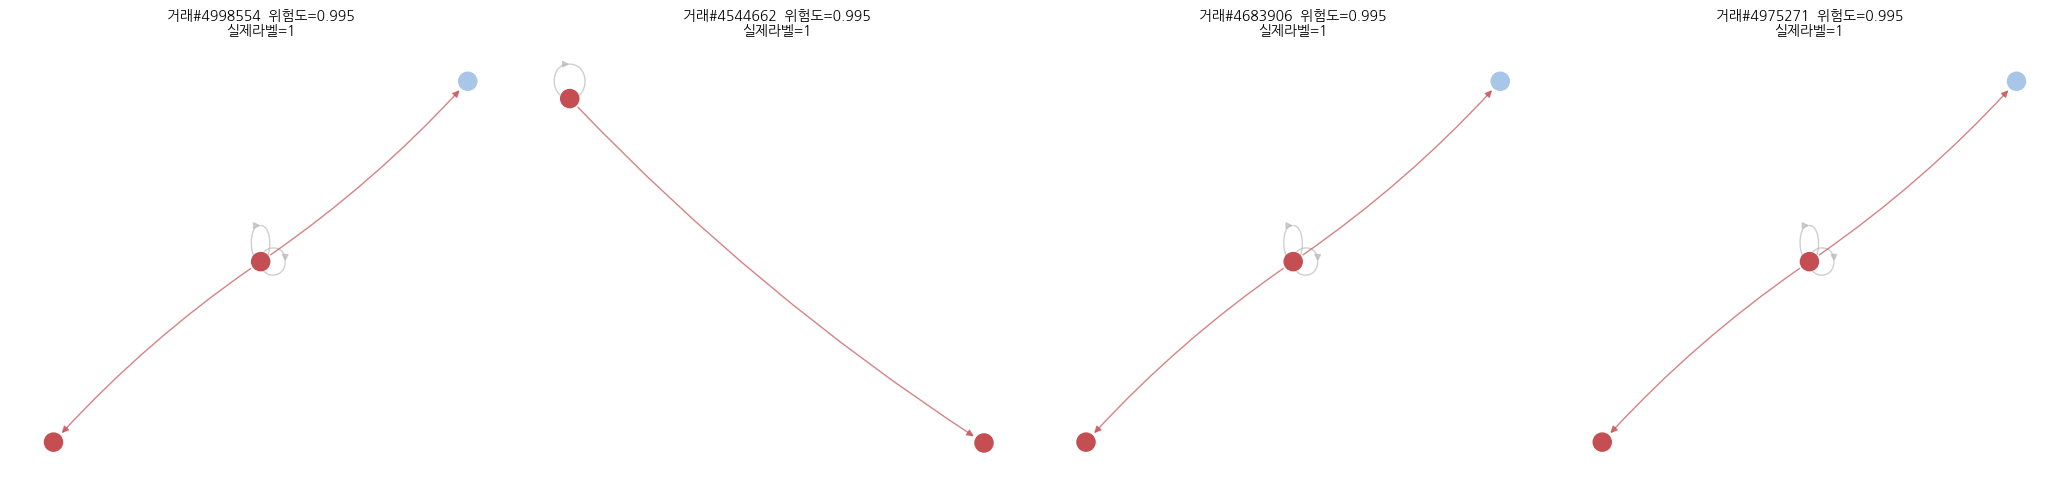

조사노트 4건 저장 -> ./case_notes/


In [33]:
TOP_K = 4
CONTEXT_EDGES = 50_000
os.makedirs("case_notes", exist_ok=True)

test_global_idx = np.arange(n_va, n)
top_local = np.argsort(-test_prob)[:TOP_K]
top_global = test_global_idx[top_local]

fig, axes = plt.subplots(1, TOP_K, figsize=(5.2 * TOP_K, 5))
axes = np.atleast_1d(axes)

for ax, gi, li in zip(axes, top_global, top_local):
    row = df.iloc[gi]
    lo = max(0, gi - CONTEXT_EDGES)
    ctx = df.iloc[lo:gi + 1]
    center_nodes = {int(row["src_id"]), int(row["dst_id"])}
    nb = ctx[ctx["src_id"].isin(center_nodes) | ctx["dst_id"].isin(center_nodes)].tail(60)

    G = nx.MultiDiGraph()
    for _, r in nb.iterrows():
        G.add_edge(int(r["src_id"]), int(r["dst_id"]), laundering=int(r["Is Laundering"]))
    pos_l = nx.spring_layout(G, seed=SEED, k=1.0)
    ncolors = ["#C44E52" if v in center_nodes else "#A8C6E8" for v in G.nodes()]
    ecolors = ["#C44E52" if a.get("laundering") else "#BBBBBB" for _, _, a in G.edges(data=True)]
    nx.draw_networkx_nodes(G, pos_l, ax=ax, node_size=170, node_color=ncolors)
    nx.draw_networkx_edges(G, pos_l, ax=ax, edge_color=ecolors, arrows=True, alpha=0.7,
                           connectionstyle="arc3,rad=0.06")
    ax.set_title(f"거래#{gi}  위험도={test_prob[li]:.3f}\n실제라벨={int(row['Is Laundering'])}",
                 fontsize=10)
    ax.axis("off")

    note = {
        "transaction_order_idx": int(gi),
        "risk_score": float(test_prob[li]),
        "threshold": TUNED_THR,
        "from": f"{row['From Bank']}_{row['Account']}",
        "to": f"{row['To Bank']}_{row['Account.1']}",
        "amount_paid": float(row["Amount Paid"]), "payment_currency": str(row["Payment Currency"]),
        "amount_received": float(row["Amount Received"]), "receiving_currency": str(row["Receiving Currency"]),
        "payment_format": str(row["Payment Format"]),
        "neighborhood_tx_count": int(len(nb)),
        "neighborhood_laundering_count": int(nb["Is Laundering"].sum()),
        "investigator_notes": "",          # 조사자가 심층 분석 후 기입 (화두 4)
        "linked_str_draft": None,          # MVP 이후: STR 초안 LLM 연계 슬롯
    }
    with open(f"case_notes/case_{gi}.json", "w", encoding="utf-8") as fp:
        json.dump(note, fp, ensure_ascii=False, indent=2)

plt.tight_layout(); plt.show()
print(f"조사노트 {TOP_K}건 저장 -> ./case_notes/")

## 13. 분 단위 배치 추론 데모 (화두 2)

- 입력: **분 단위로 묶인 거래 배치** (배치 내 첫 거래 도착 시각 기준)
- 각 배치는 "직전 `CONTEXT_EDGES`건의 과거 거래"를 그래프 컨텍스트로 사용 (사후 탐지 — 화두 3)
- 배치별 처리 지연을 측정합니다. `Timestamp`는 **배치를 묶는 용도로만** 쓰고 모델 피처가 아닙니다(화두 10).

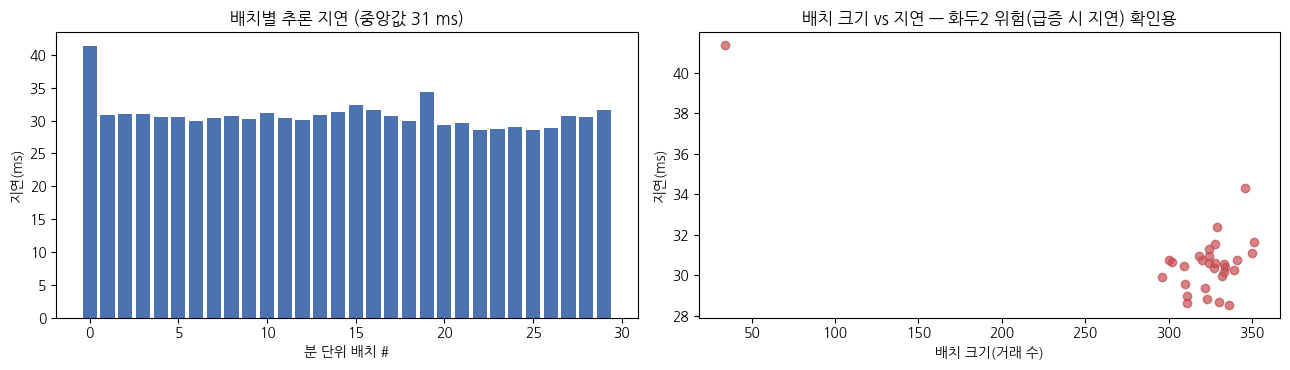

In [34]:
@torch.no_grad()
def score_batch(batch_end_gi, batch_size):
    # [batch_end_gi-batch_size+1, batch_end_gi] 거래를, 과거 컨텍스트와 함께 채점
    lo = max(0, batch_end_gi + 1 - batch_size - CONTEXT_EDGES)
    hi = batch_end_gi + 1
    x, ei, ea, y, m = build_window(lo, hi)
    model.eval()
    logit = model(x.to(DEVICE), ei.to(DEVICE), ea.to(DEVICE), m)
    prob = torch.sigmoid(logit).cpu().numpy()
    return prob[-batch_size:]

test_df = df.iloc[n_va:]
minute_groups = test_df.groupby(test_df["Timestamp"].dt.floor("min"), sort=True)

N_DEMO = 30
lat_ms, sizes = [], []
for i, (minute, g) in enumerate(minute_groups):
    if i >= N_DEMO:
        break
    t_start = time.perf_counter()          # 배치 첫 도착 기준 시각(가정)
    probs = score_batch(int(g["order_idx"].iloc[-1]), len(g))
    dt = (time.perf_counter() - t_start) * 1000
    lat_ms.append(dt); sizes.append(len(g))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].bar(range(len(lat_ms)), lat_ms, color="#4C72B0")
axes[0].set_xlabel("분 단위 배치 #"); axes[0].set_ylabel("지연(ms)")
axes[0].set_title(f"배치별 추론 지연 (중앙값 {np.median(lat_ms):.0f} ms)")
axes[1].scatter(sizes, lat_ms, color="#C44E52", alpha=0.7)
axes[1].set_xlabel("배치 크기(거래 수)"); axes[1].set_ylabel("지연(ms)")
axes[1].set_title("배치 크기 vs 지연 — 화두2 위험(급증 시 지연) 확인용")
plt.tight_layout(); plt.show()

## 14. 모델·설정 저장 (배포/재현용)

In [35]:
os.makedirs("artifacts", exist_ok=True)
torch.save(model.state_dict(), f"artifacts/{DATASET}_edge_gine.pt")
with open(f"artifacts/{DATASET}_config.json", "w", encoding="utf-8") as fp:
    json.dump({
        "dataset": DATASET, "seed": SEED,
        "edge_features": EDGE_FEATURES, "node_dim": NODE_DIM, "edge_dim": EDGE_DIM,
        "hidden": HIDDEN, "layers": N_LAYERS, "dropout": DROPOUT,
        "window_size": WINDOW_SIZE, "context_edges": CONTEXT_EDGES,
        "tuned_threshold": TUNED_THR, "best_val_pr_auc": float(best_ap),
        "test_pr_auc": float(test_ap),
        "pf_cats": PF_CATS, "pc_cats": PC_CATS, "rc_cats": RC_CATS,
        "tail_min_frac": TAIL_MIN_FRAC,
        "main_period": [str(main_start.date()), str(main_end.date())],
    }, fp, ensure_ascii=False, indent=2)
print("저장 완료 -> ./artifacts/")

저장 완료 -> ./artifacts/


## 15. 결론 및 다음 단계

### 이 노트북이 한 일
1. SSRN 10편 검토 → AML 직접 관련 논문 부재를 확인하고, IBM AMLworld 벤치마크 최고 성능 계열
   (**방향 멀티그래프 GNN 엣지 분류**, Egressy et al. AAAI 2024)을 채택
2. 팀 화두 결론 17건을 코드에 1:1 반영 + 각 결론의 위험성 경고 명시
3. 팀원 GBT+GFP 방식과 **완전히 다른 접근**(end-to-end GNN, 절대시간 미사용, 통화별 표준화,
   계좌 임베딩 미사용)으로 일반화 우선 설계

### 다음 단계 제안
- **세트 간 비교 (화두 7):** `DATASET = "LI-Small"` 등으로 바꿔 전체 재실행 → 세트별 성능 비교표 작성
- **다중 시드 평가:** `SEED`를 0~3으로 바꿔 4회 실행, 평균±표준편차 보고 (팀원 프로토콜과 비교 가능)
- **팀원 GBT 결과와 교차 검증:** 동일 분할·동일 지표(소수클래스 F1)로 나란히 비교
- **케이스 조사 → STR 초안:** `case_notes/*.json` 을 입력으로 LLM STR 초안 생성 모듈 연결 (MVP 이후)
- **성능 미달 시:** ① 윈도우 크기/레이어 수 확대 ② MEGA-GNN식 다중엣지 집계 도입
  ③ 화두 10 재논의(상대 시간차 피처 제한 도입)